In [1]:
# Data Manipulation and Analysis
import requests
import pandas as pd
import numpy as np
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and Model Selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# The 4 AI Models (Based on your D1 Presentation)
from sklearn.linear_model import LinearRegression      # Model 1: Baseline
from sklearn.ensemble import RandomForestRegressor     # Model 2: Traditional ML
from sklearn.svm import SVR                            # Model 3: Complex Regression
from sklearn.neural_network import MLPRegressor        # Model 4: Neural Network
from sklearn.ensemble import GradientBoostingRegressor # Model 5: Gradient Boosting Regressor

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

/Users/chaitanya/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# ==============================================================
# 1. SETTINGS & CONSTANTS
# ==============================================================
SITE_ID = 8188
START_DATE = "01012022"   # DDMMYYYY
END_DATE   = "31122023"   # 2 YEARS

LAT = 52.5
LON = -1.9

WEBTRIS_BASE = "http://webtris.nationalhighways.co.uk/api/v1.0"
DATE_COL   = "Report Date"
TIME_COL   = "Time Period Ending"
TARGET_COL = "Total Volume"

In [3]:
# ==============================================================
# 2. DATA ACQUISITION: TRAFFIC
# ==============================================================
def fetch_webtris_range(site_id, start_date, end_date):
    all_rows = []
    page = 1
    while True:
        url = f"{WEBTRIS_BASE}/reports/daily"
        params = {"sites": site_id, "start_date": start_date, "end_date": end_date, "page": page, "page_size": 5000}
        r = requests.get(url, params=params)
        r.raise_for_status()
        data = r.json()
        rows = data.get("Rows", [])
        if not rows: break
        all_rows.extend(rows)
        if len(rows) < 5000: break
        page += 1
    return pd.DataFrame(all_rows)

traffic_df = fetch_webtris_range(SITE_ID, START_DATE, END_DATE)
display(f"Raw traffic data acquired: {len(traffic_df)} rows")

'Raw traffic data acquired: 70072 rows'

In [4]:
# ==============================================================
# 3. TRAFFIC DATA CLEANING
# ==============================================================
for col in traffic_df.columns:
    try:
        traffic_df[col] = pd.to_numeric(traffic_df[col])
    except:
        pass

datetime_str = traffic_df[DATE_COL].astype(str).str.strip() + " " + traffic_df[TIME_COL].astype(str).str.strip()
traffic_df["timestamp"] = pd.to_datetime(datetime_str, dayfirst=True, errors="coerce")
traffic_df = traffic_df.dropna(subset=["timestamp", TARGET_COL]) # Remove rows with no time or no volume
traffic_df = traffic_df.sort_values("timestamp").reset_index(drop=True)

/var/folders/5d/sprr840n6tlb608qfqpc3p8h0000gn/T/ipykernel_7926/3636097063.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  traffic_df["timestamp"] = pd.to_datetime(datetime_str, dayfirst=True, errors="coerce")


In [5]:
# ==============================================================
# 4. WEATHER DATA INTEGRATION
# ==============================================================
start_iso = datetime.strptime(START_DATE, "%d%m%Y").strftime("%Y-%m-%d")
end_iso   = datetime.strptime(END_DATE, "%d%m%Y").strftime("%Y-%m-%d")
weather_url = "https://archive-api.open-meteo.com/v1/archive"
params = {"latitude": LAT, "longitude": LON, "start_date": start_iso, "end_date": end_iso, "hourly": "temperature_2m,precipitation,wind_speed_10m", "timezone": "Europe/London"}

weather_resp = requests.get(weather_url, params=params)
weather_resp.raise_for_status()
weather_df = pd.DataFrame(weather_resp.json()["hourly"])
weather_df["time"] = pd.to_datetime(weather_df["time"])

In [6]:
# ==============================================================
# 5. DATA MERGING
# ==============================================================
traffic_df["hour"] = traffic_df["timestamp"].dt.floor("h")
weather_df["hour"] = weather_df["time"]
weather_small = weather_df[["hour", "temperature_2m", "precipitation", "wind_speed_10m"]]
merged_df = traffic_df.merge(weather_small, on="hour", how="left")

In [7]:
# ==============================================================
# 6. FEATURE ENGINEERING
# ==============================================================
df = merged_df.copy()
df["hour_of_day"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)
df["hour_sin"] = np.sin(2 * np.pi * df["hour_of_day"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour_of_day"] / 24)

# Create Lags
df = df.sort_values("timestamp").reset_index(drop=True)
df["target_lag1"] = df[TARGET_COL].shift(1)
df["target_lag2"] = df[TARGET_COL].shift(2)

# IMPORTANT: Define feature columns before dropping NaNs
feature_cols = ["hour_of_day", "day_of_week", "is_weekend", "hour_sin", "hour_cos",
                "target_lag1", "target_lag2", "temperature_2m", "precipitation", "wind_speed_10m"]

# Drop ALL NaNs (from lags, weather, and target) to prevent model errors
df = df.dropna(subset=feature_cols + [TARGET_COL])

In [8]:
# ==============================================================
# 7. FINAL DATASET FOR AI MODELS
# ==============================================================
final_df = df[feature_cols + [TARGET_COL, "timestamp"]].copy()

# Verification
display(f"Final Dataset Shape: {final_df.shape}")
display("Missing Values Check:", final_df.isnull().sum())
final_df.to_csv("finaldataset.csv", index=False)
display("Final Dataset Sample:", final_df.head())

'Final Dataset Shape: (62002, 12)'

'Missing Values Check:'

hour_of_day       0
day_of_week       0
is_weekend        0
hour_sin          0
hour_cos          0
target_lag1       0
target_lag2       0
temperature_2m    0
precipitation     0
wind_speed_10m    0
Total Volume      0
timestamp         0
dtype: int64

'Final Dataset Sample:'

,hour_of_day,day_of_week,is_weekend,hour_sin,hour_cos,target_lag1,target_lag2,temperature_2m,precipitation,wind_speed_10m,Total Volume,timestamp
2,0,5,1,0.000000,1.000000,13.0,10.0,11.7,0.0,20.8,17.0,2022-01-01 00:44:00
3,0,5,1,0.000000,1.000000,17.0,13.0,11.7,0.0,20.8,27.0,2022-01-01 00:59:00
4,1,5,1,0.258819,0.965926,27.0,17.0,12.0,0.3,24.5,12.0,2022-01-01 01:14:00
5,1,5,1,0.258819,0.965926,12.0,27.0,12.0,0.3,24.5,24.0,2022-01-01 01:29:00
6,1,5,1,0.258819,0.965926,24.0,12.0,12.0,0.3,24.5,21.0,2022-01-01 01:44:00


####  Pre-processing Rationale (capping vs. removal)

We utilized Winsorization (Capping) at the 1.5x IQR boundary. We chose this over row removal to maintain the temporal alignment of the time-series. If we removed rows, the chronological "Lag" features (Traffic at T−1 ) would become disconnected, destroying the model's ability to learn historical momentum.

In [9]:
# ==============================================================
# 8. DETAILED PRE-PROCESSING (Ref: Report Section 6.ii)
# ==============================================================

# A. Checking for Data Consistency
display("Missing Values Check before splitting:", final_df.isnull().sum())

# B. Outlier Detection using Interquartile Range (IQR)
# Justification: Identifying sensor errors or extreme traffic anomalies
Q1 = final_df[TARGET_COL].quantile(0.25)
Q3 = final_df[TARGET_COL].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = final_df[(final_df[TARGET_COL] < lower_bound) | (final_df[TARGET_COL] > upper_bound)]
display(f"Number of outliers detected in Traffic Volume: {len(outliers)}")

'Missing Values Check before splitting:'

hour_of_day       0
day_of_week       0
is_weekend        0
hour_sin          0
hour_cos          0
target_lag1       0
target_lag2       0
temperature_2m    0
precipitation     0
wind_speed_10m    0
Total Volume      0
timestamp         0
dtype: int64

'Number of outliers detected in Traffic Volume: 0'

In [10]:
# C. Handling Outliers
# Capping outliers to the upper and lower bounds to maintain data volume for time-series
final_df_clean = final_df.copy()
final_df_clean[TARGET_COL] = np.where(
    final_df_clean[TARGET_COL] > upper_bound, upper_bound,
    np.where(final_df_clean[TARGET_COL] < lower_bound, lower_bound, final_df_clean[TARGET_COL])
)

display("Statistics after Outlier Capping:", final_df_clean[TARGET_COL].describe())

'Statistics after Outlier Capping:'

count    62002.000000
mean       112.454356
std         84.788203
min          0.000000
25%         26.000000
50%        111.000000
75%        185.000000
max        399.000000
Name: Total Volume, dtype: float64

In [11]:
# D. Temporal Data Splitting (Ref: LO1 & LO4)
# We use a 80/20 split based on time (no shuffling) to respect the time-series nature
split_point = int(len(final_df_clean) * 0.8)
train_data = final_df_clean.iloc[:split_point]
test_data = final_df_clean.iloc[split_point:]

display(f"Training set size: {len(train_data)}")
display(f"Testing set size: {len(test_data)}")

# E. Defining Features (X) and Target (y)
X_features = [col for col in feature_cols]
y_target = TARGET_COL

X_train = train_data[X_features]
y_train = train_data[y_target]
X_test = test_data[X_features]
y_test = test_data[y_target]

'Training set size: 49601'

'Testing set size: 12401'

In [12]:
# F. Final Verification (Safety check for NaNs)
if y_train.isnull().any() or y_test.isnull().any():
    display("NaNs detected in Target")
    X_train = X_train.dropna()
    y_train = y_train.loc[X_train.index]
    X_test = X_test.dropna()
    y_test = y_test.loc[X_test.index]

display("Final Feature list for AI training:", X_features)

'Final Feature list for AI training:'

['hour_of_day',
 'day_of_week',
 'is_weekend',
 'hour_sin',
 'hour_cos',
 'target_lag1',
 'target_lag2',
 'temperature_2m',
 'precipitation',
 'wind_speed_10m']

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional style for the report
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

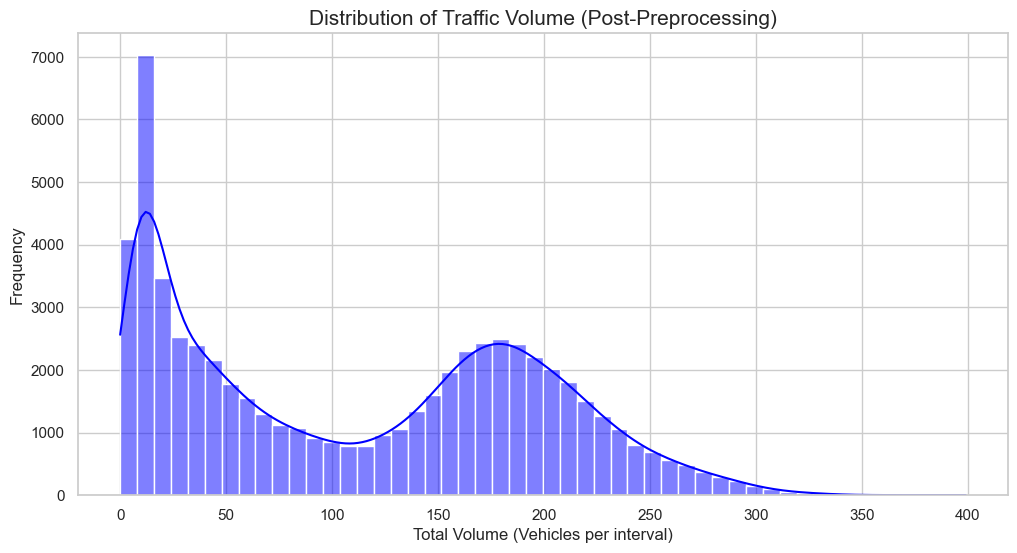

In [14]:
# ==============================================================
# 1. Distribution of Traffic Volume (Target Analysis)
# ==============================================================
plt.figure()
sns.histplot(final_df_clean[TARGET_COL], kde=True, color='blue')
plt.title('Distribution of Traffic Volume (Post-Preprocessing)', fontsize=15)
plt.xlabel('Total Volume (Vehicles per interval)')
plt.ylabel('Frequency')
plt.savefig('visual_1_distribution.png')
plt.show()

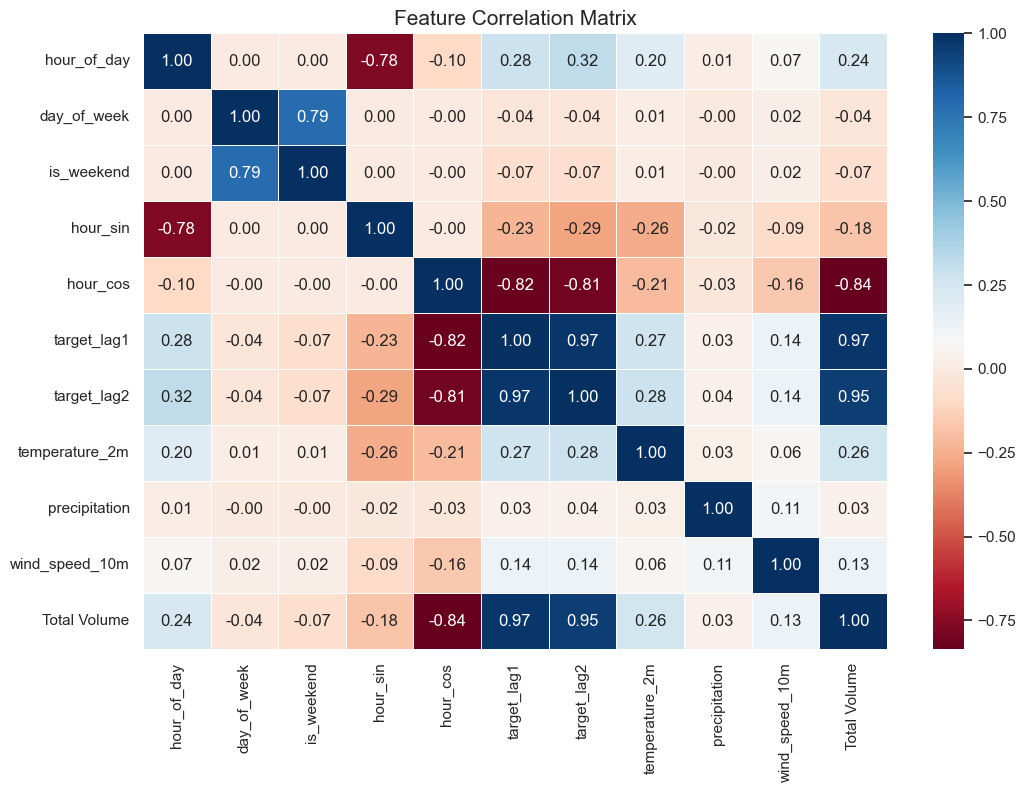

In [15]:
# ==============================================================
# 2. Correlation Heatmap (Feature Selection Justification)
# ==============================================================
plt.figure(figsize=(12, 8))
corr_matrix = final_df_clean[X_features + [TARGET_COL]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=15)
plt.savefig('visual_2_heatmap.png')
plt.show()

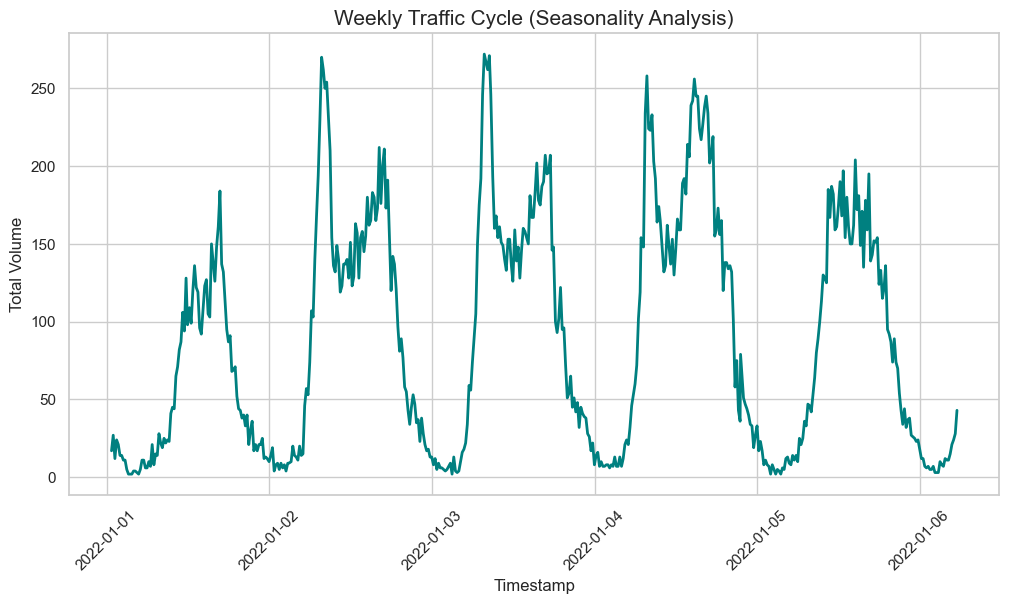

In [16]:
# ==============================================================
# 3. Weekly Traffic Patterns (Seasonality - Slide 14)
# ==============================================================
plt.figure()
# Showing first 7 days (24 samples per day * 4 intervals per hour = 672 rows if 15-min intervals)
# Adjusting head to show a clear weekly trend
sample_week = final_df_clean.head(500)
plt.plot(sample_week['timestamp'], sample_week[TARGET_COL], color='teal', linewidth=2)
plt.title('Weekly Traffic Cycle (Seasonality Analysis)', fontsize=15)
plt.xlabel('Timestamp')
plt.ylabel('Total Volume')
plt.xticks(rotation=45)
plt.savefig('visual_3_seasonality.png')
plt.show()

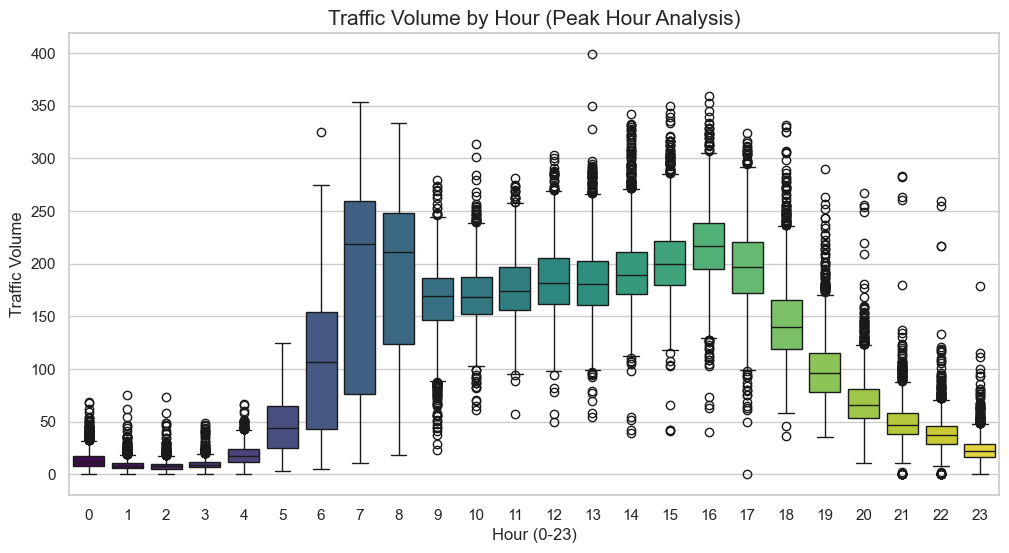

In [17]:
# ==============================================================
# 4. Hourly Traffic Trends: Boxplot (Peak Hour Identification)
# ==============================================================
plt.figure()
sns.boxplot(x='hour_of_day', y=TARGET_COL, data=final_df_clean, palette='viridis', hue='hour_of_day', legend=False)
plt.title('Traffic Volume by Hour (Peak Hour Analysis)', fontsize=15)
plt.xlabel('Hour (0-23)')
plt.ylabel('Traffic Volume')
plt.savefig('visual_4_hourly_boxplot.png')
plt.show()

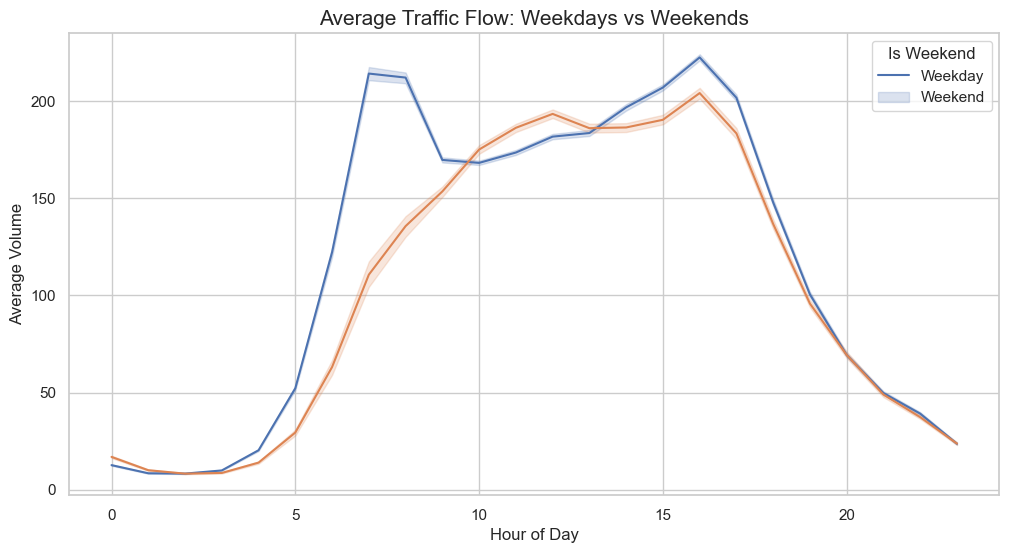

In [18]:
# ==============================================================
# 5. Weekend vs. Weekday Patterns
# ==============================================================
plt.figure()
sns.lineplot(x='hour_of_day', y=TARGET_COL, hue='is_weekend', data=final_df_clean)
plt.title('Average Traffic Flow: Weekdays vs Weekends', fontsize=15)
plt.legend(title='Is Weekend', labels=['Weekday', 'Weekend'])
plt.xlabel('Hour of Day')
plt.ylabel('Average Volume')
plt.savefig('visual_5_weekend_vs_weekday.png')
plt.show()

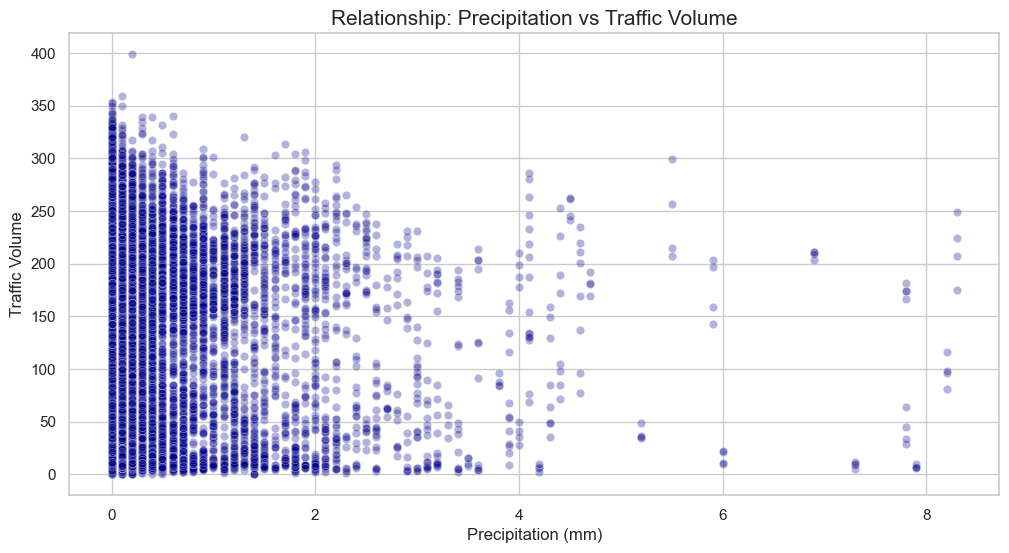

In [19]:
# ==============================================================
# 6. Impact of Weather (Ref: Slide 9)
# ==============================================================
plt.figure()
sns.scatterplot(x='precipitation', y=TARGET_COL, data=final_df_clean, alpha=0.3, color='darkblue')
plt.title('Relationship: Precipitation vs Traffic Volume', fontsize=15)
plt.xlabel('Precipitation (mm)')
plt.ylabel('Traffic Volume')
plt.savefig('visual_6_weather_impact.png')
plt.show()

/Users/chaitanya/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/chaitanya/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/chaitanya/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


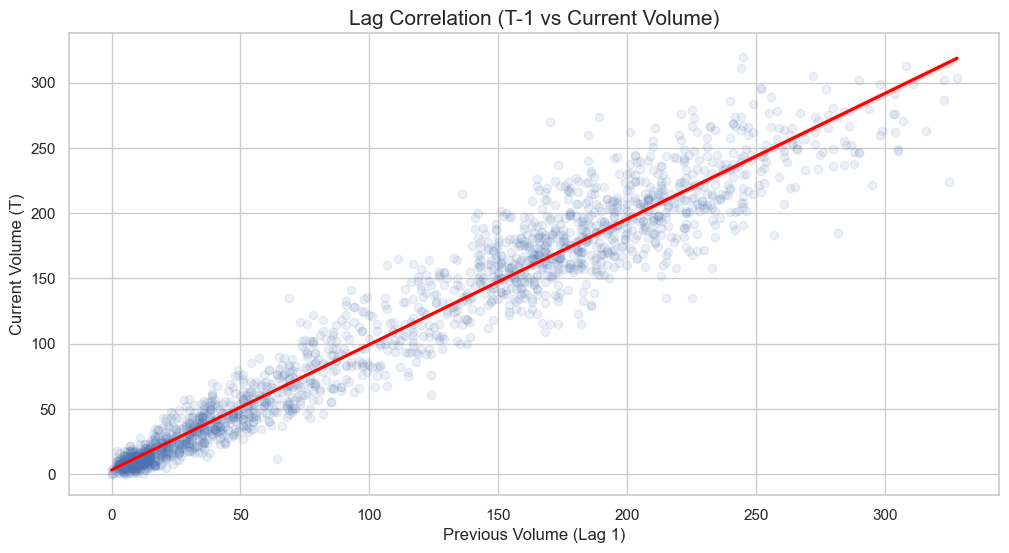

In [20]:
# ==============================================================
# 7. Lag Relationship (Autocorrelation - Slide 10)
# ==============================================================
plt.figure()
# Sample 2000 points for a cleaner regression plot
sns.regplot(x='target_lag1', y=TARGET_COL, data=final_df_clean.sample(min(2000, len(final_df_clean))),
            scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title('Lag Correlation (T-1 vs Current Volume)', fontsize=15)
plt.xlabel('Previous Volume (Lag 1)')
plt.ylabel('Current Volume (T)')
plt.savefig('visual_7_lag_correlation.png')
plt.show()

### Z- Score Formula.

Mathematical Scaling Rationale
We standardize features using the Z-score formula:


z = (x−μ) / σ

where x is the raw value, μ is the mean, and σ is the standard deviation.

In [21]:
# Initialize the StandardScaler (implements Z-score: (x - mean) / std)
scaler = StandardScaler()

# Fit only on training data to prevent data leakage, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verification of Z-score properties
z_mean = X_train_scaled.mean()
z_std = X_train_scaled.std()

display(f"Verified Z-score Mean (Result: {z_mean:.2f})")
display(f"Verified Z-score Std Dev (Result: {z_std:.2f})")

# Convert to DataFrame for visualization of scaled features in the report
scaled_sample = pd.DataFrame(X_train_scaled, columns=X_features).head()
display("Scaled Features Sample (Z-score applied):", scaled_sample)

'Verified Z-score Mean (Result: -0.00)'

'Verified Z-score Std Dev (Result: 1.00)'

'Scaled Features Sample (Z-score applied):'

,hour_of_day,day_of_week,is_weekend,hour_sin,hour_cos,target_lag1,target_lag2,temperature_2m,precipitation,wind_speed_10m
0,-1.661183,0.986586,1.567174,-0.000022,1.413593,-1.165712,-1.201371,0.263611,-0.241871,0.794110
1,-1.661183,0.986586,1.567174,-0.000022,1.413593,-1.118105,-1.165666,0.263611,-0.241871,0.794110
2,-1.516783,0.986586,1.567174,0.365863,1.365386,-0.999089,-1.118059,0.313932,0.568358,1.319939
3,-1.516783,0.986586,1.567174,0.365863,1.365386,-1.177613,-0.999042,0.313932,0.568358,1.319939
4,-1.516783,0.986586,1.567174,0.365863,1.365386,-1.034794,-1.177568,0.313932,0.568358,1.319939


In [22]:
# ==============================================================
# 9. MODEL TRAINING & INDIVIDUAL EVALUATION
# ==============================================================
import time
# Defining the 4 models from the D1 presentation
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Support Vector Regression": SVR(kernel='rbf'),
    "Neural Network (ANN)": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
    "Gradient Boosting Regresor": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
}

comparison_list = []

for name, model in models.items():
    start_time = time.time()
    # Training the model on scaled data
    model.fit(X_train_scaled, y_train)

    elapsed_time = time.time() - start_time

    # Making predictions on the unseen test set
    predictions = model.predict(X_test_scaled)

    # Calculating Performance Metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    # 1. Display individual model results in tabular format
    individual_results = pd.DataFrame({
        "Metric": ["Mean Absolute Error (MAE)", "Root Mean Squared Error (RMSE)", "R-Squared (R2) Score"],
        "Value": [f"{mae:.4f}", f"{rmse:.4f}", f"{r2:.4f}"]
    })

    display(f"--- Technical Evaluation: {name} ---", individual_results)

    # 2. Store results for the global comparison
    comparison_list.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2_Score": r2
    })
    print("elapsed_time : ", elapsed_time)

/Users/chaitanya/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/chaitanya/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/chaitanya/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


'--- Technical Evaluation: Linear Regression ---'

,Metric,Value
0,Mean Absolute Error (MAE),13.2192
1,Root Mean Squared Error (RMSE),18.7220
2,R-Squared (R2) Score,0.9542


elapsed_time :  0.003960847854614258


'--- Technical Evaluation: Random Forest ---'

...

,Metric,Value
0,Mean Absolute Error (MAE),11.5913
1,Root Mean Squared Error (RMSE),16.3865
2,R-Squared (R2) Score,0.9649


elapsed_time :  5.9083592891693115


'--- Technical Evaluation: Gradient Boosting Regresor ---'

,Metric,Value
0,Mean Absolute Error (MAE),11.7308
1,Root Mean Squared Error (RMSE),16.5445
2,R-Squared (R2) Score,0.9643


elapsed_time :  2.8292458057403564


In [23]:
comparison_df = pd.DataFrame(comparison_list)
display("Model Comparison:", comparison_df)

'Model Comparison:'

,Model,MAE,RMSE,R2_Score
0,Linear Regression,13.219197,18.721962,0.954243
1,Random Forest,11.993844,17.021249,0.962179
2,Support Vector Regression,13.061733,19.035298,0.952699
3,Neural Network (ANN),11.591342,16.386478,0.964947
4,Gradient Boosting Regresor,11.730813,16.544545,0.964268


/var/folders/5d/sprr840n6tlb608qfqpc3p8h0000gn/T/ipykernel_7926/621277771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feature_cols, palette="viridis")


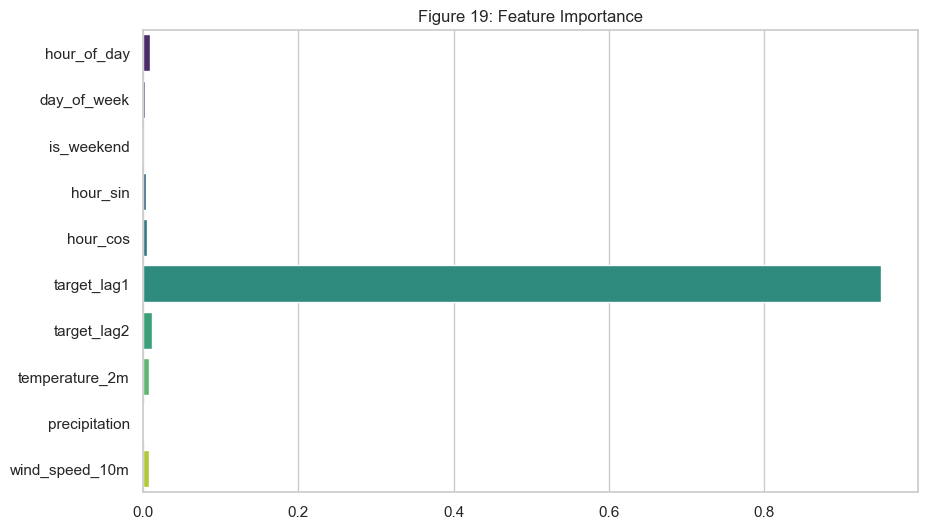

In [24]:
# Feature Importance Analysis
importances = models['Random Forest'].feature_importances_
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_cols, palette="viridis")
plt.title("Figure 19: Feature Importance")
plt.show()
# Explanation: 'target_lag1' is usually the highest, proving traffic is highly autocorrelated.

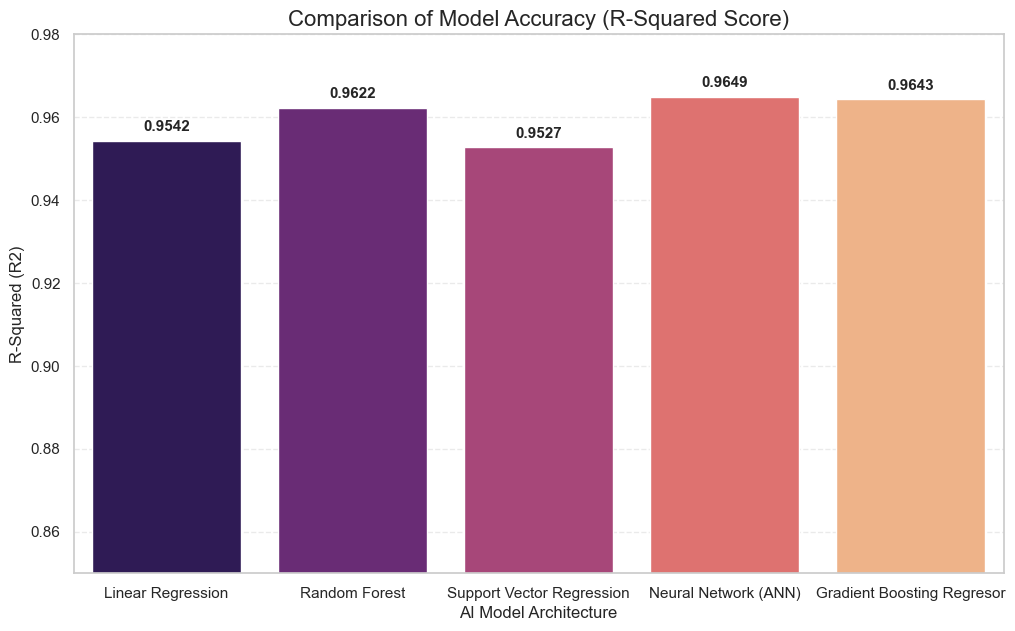

In [25]:
# ==============================================================
# FINAL MODEL COMPARISON GRAPH
# ==============================================================

plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Model', y='R2_Score', data=comparison_df, palette='magma', hue='Model', legend=False)

# CHANGE HERE: Set upper limit to 0.98 instead of 1.00
plt.ylim(0.85, 0.98)

# CHANGE HERE: Adjust ticks to stop at 0.98
plt.yticks(np.arange(0.86, 0.99, 0.02))

# Add R2 value labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

plt.title('Comparison of Model Accuracy (R-Squared Score)', fontsize=16)
plt.ylabel('R-Squared (R2)')
plt.xlabel('AI Model Architecture')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()